In [99]:
import pandas as pd

In [100]:
df = pd.read_csv('/content/drive/MyDrive/llm_price_performance_tracker_2026-03-31.csv')

In [101]:
#df["blended_cost_usd_per_1m"] = df["blended_cost_usd_per_1m"].fillna(0)
#df["pricing_tier"] = df["pricing_tier"].replace("Unknown", "Budget")
df = df.dropna(subset=["blended_cost_usd_per_1m"])
print(len(df))

315


Drop null values in the dataset where blended_cost_usd_per_1m = N/A since thats unreported data. We cannott assume it is 0 since that might mess up later computations

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#Numerical features that we will be focusing on
FEATURES_BASE = [
    "aa_intelligence_index",
    "composite_benchmark",
    "output_tokens_per_second",
    "time_to_first_token_s",
]

TARGET = "blended_cost_usd_per_1m"

#Add pricing tier and provider and model name as categorical variables and drop any rows where any value is null
df_train = df[FEATURES_BASE + ["pricing_tier", "provider", "model_name", TARGET]].dropna(subset=FEATURES_BASE + [TARGET])
model_names = df_train["model_name"].copy()

#We have to get the model names here or else it will be much harder to get pricing tier later after its encoded
top3_budget = df_train[df_train["pricing_tier"] == "Budget"].nlargest(3, "composite_benchmark")
#print(top3_budget['model_name'])
top3_Mid = df_train[df_train["pricing_tier"] == "Mid"].nlargest(3, "composite_benchmark")
#print(top3_Mid['model_name'])
top3_Premium = df_train[df_train["pricing_tier"] == "Premium"].nlargest(3, "composite_benchmark")
#print(top3_Premium['model_name'])
top3_Ultra = df_train[df_train["pricing_tier"] == "Ultra"].nlargest(3, "composite_benchmark")
#print(top3_Ultra['model_name'])

top_models = pd.concat([top3_budget, top3_Mid, top3_Premium, top3_Ultra])
top_model_names = top_models["model_name"].tolist()
print(f"Total models selected: {len(top_model_names)}")
print(top_model_names)


#save the model names since it will mess up later computations
df_train = df_train.drop(columns=["model_name"])
df_train = pd.get_dummies(df_train, columns=["pricing_tier", "provider"], drop_first=True)
df_train["model_name"] = model_names


#encode the categorical variables
tier_cols = [c for c in df_train.columns if "pricing_tier" in c]
prov_cols = [c for c in df_train.columns if "provider" in c]

#we ignore nodel name since it isnt important right now
FEATURES  = FEATURES_BASE + tier_cols + prov_cols

#Split our data into 70% train and 30% test using log transform on the target varaible since the variance is so high it will pull the outliers towards the mean
X = df_train[FEATURES]
y = np.log1p(df_train[TARGET])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#use a Ridge model since it gives a penalty for large coefficients
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

#since we got the log of the target before we have to use the exponential to get the real value back
y_pred = np.expm1(model.predict(X_test_scaled))
y_test_actual = np.expm1(y_test)

mse = mean_squared_error(y_test_actual, y_pred)
r2  = r2_score(y_test_actual, y_pred)
print(f"\nMSE  : {mse:.4f}")
print(f"RMSE : {mse**0.5:.4f}  (in $/1M tokens)")
print(f"R²   : {r2:.4f}")

Total models selected: 12
['Grok 3 mini Reasoning (high)', 'Llama Nemotron Super 49B v1.5 (Reasoning)', 'DeepSeek V3.2 (Reasoning)', 'GPT-5 (high)', 'Gemini 3 Pro Preview (high)', 'o4-mini (high)', 'Grok 4', 'Claude Opus 4.5 (Reasoning)', 'Claude 4 Sonnet (Reasoning)', 'o3-pro', 'Claude 4 Opus (Reasoning)', 'Claude 4 Opus (Non-reasoning)']

MSE  : 5.7942
RMSE : 2.4071  (in $/1M tokens)
R²   : 0.8521


Our error is give or take about \$2 per million tokens which is better then our previous attempts which gave us \$4 per million tokens. Our R^2 score is 85.21% which means only about 15% of our data's variance is unexplained

In [103]:
top_df = df_train[df_train["model_name"].isin(top_model_names)][FEATURES + ["model_name", TARGET]].copy()
tier_map = df.set_index("model_name")["pricing_tier"].to_dict()
top_df["tier"] = top_df["model_name"].map(tier_map)

top_scaled = scaler.transform(top_df[FEATURES])
top_df["predicted_cost"] = np.expm1(model.predict(top_scaled))

print("\nActual vs Predicted blended cost ($/1M tokens) by tier:")
print(top_df[["tier", "model_name", TARGET, "predicted_cost"]]
      .sort_values("tier")
      .to_string(index=False))


Actual vs Predicted blended cost ($/1M tokens) by tier:
   tier                                model_name  blended_cost_usd_per_1m  predicted_cost
 Budget                 DeepSeek V3.2 (Reasoning)                    0.315        0.427954
 Budget              Grok 3 mini Reasoning (high)                    0.350        0.206192
 Budget Llama Nemotron Super 49B v1.5 (Reasoning)                    0.175        0.302820
    Mid               Gemini 3 Pro Preview (high)                    4.500        2.193888
    Mid                              GPT-5 (high)                    3.438        2.470561
    Mid                            o4-mini (high)                    1.925        2.161955
Premium               Claude Opus 4.5 (Reasoning)                   10.000        7.351755
Premium                                    Grok 4                    6.000        6.119312
Premium               Claude 4 Sonnet (Reasoning)                    6.000        6.639686
  Ultra                          

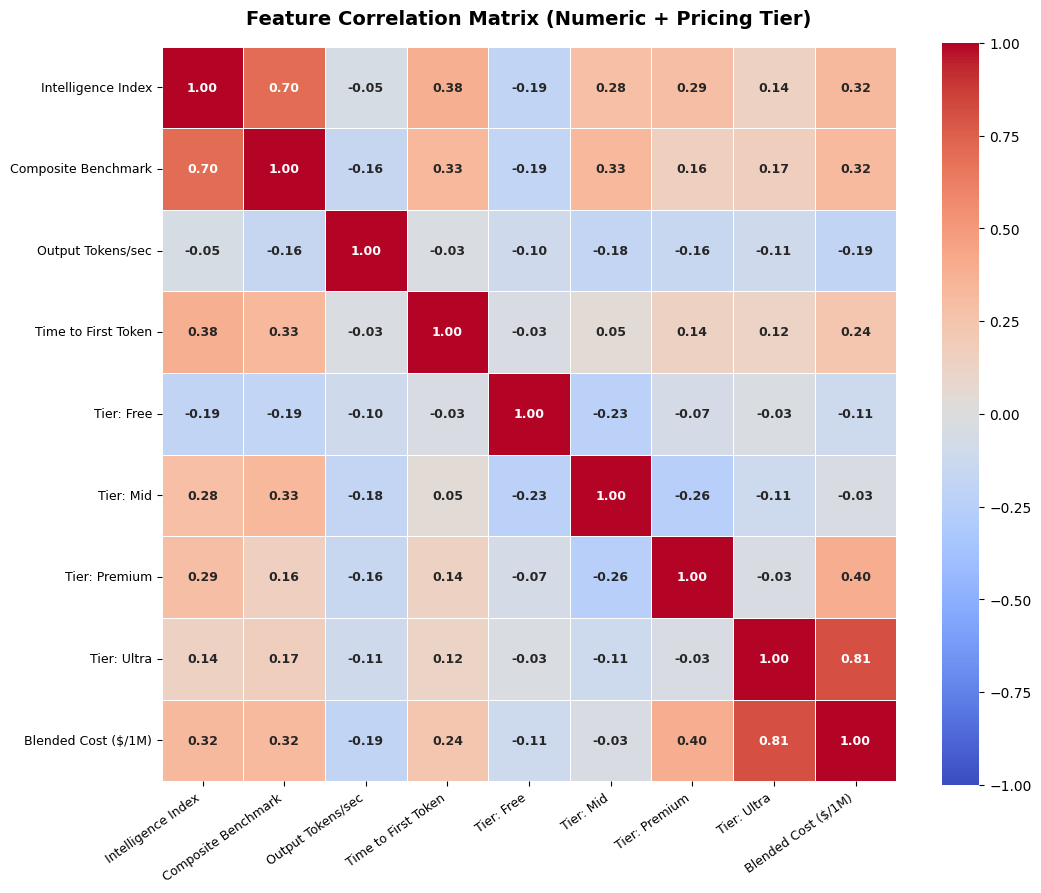

In [107]:
import seaborn as sns
cols_to_plot = [
    "aa_intelligence_index",
    "composite_benchmark",
    "output_tokens_per_second",
    "time_to_first_token_s",
] + tier_cols + [TARGET]

label_map = {
    "aa_intelligence_index":    "Intelligence Index",
    "composite_benchmark":      "Composite Benchmark",
    "output_tokens_per_second": "Output Tokens/sec",
    "time_to_first_token_s":    "Time to First Token",
    "blended_cost_usd_per_1m":  "Blended Cost ($/1M)",
}
for col in tier_cols:
    label_map[col] = "Tier: " + col.replace("pricing_tier_", "")

corr_matrix = df_train[cols_to_plot].corr().rename(index=label_map, columns=label_map)

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 9, "weight": "bold"},
    ax=ax
)

ax.set_title("Feature Correlation Matrix (Numeric + Pricing Tier)", fontsize=14, fontweight="bold", pad=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

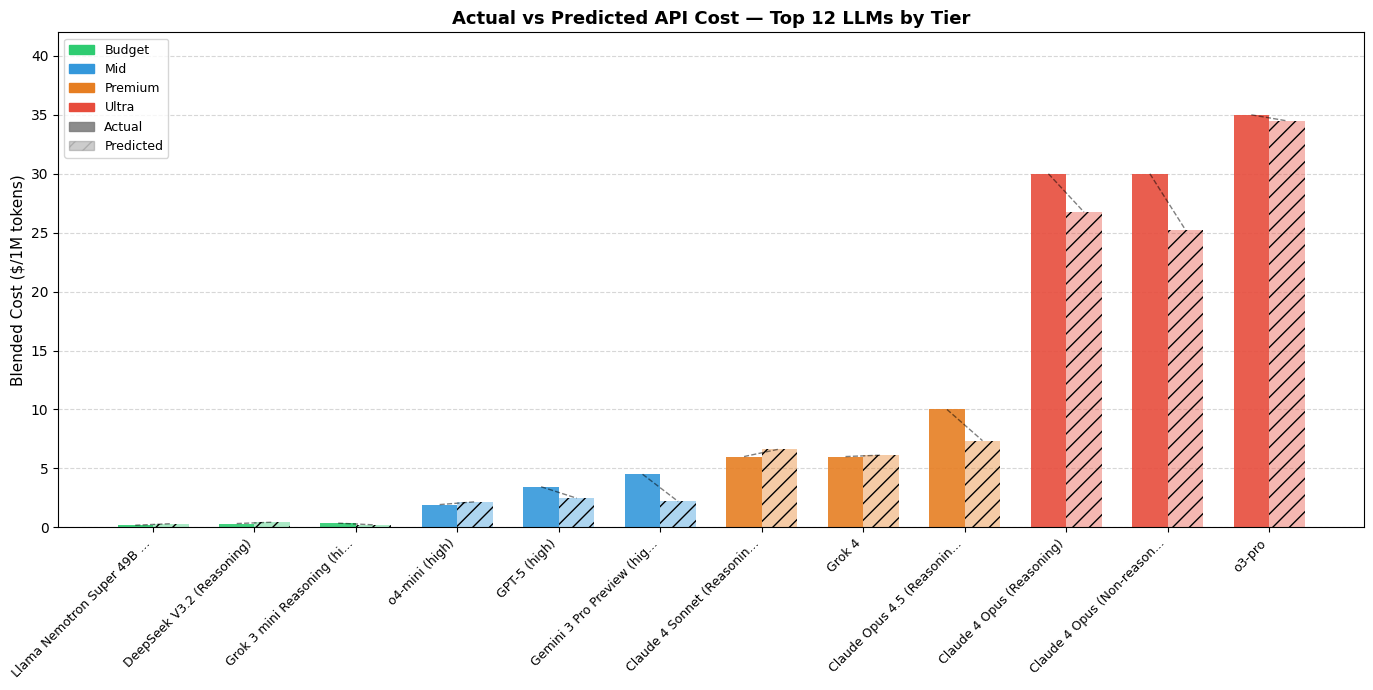

In [106]:
import matplotlib.pyplot as plt
top_df_sorted = top_df.sort_values(TARGET)

models      = top_df_sorted["model_name"].tolist()
actual      = top_df_sorted[TARGET].tolist()
predicted   = top_df_sorted["predicted_cost"].tolist()
tiers       = top_df_sorted["tier"].tolist()

short_names = [m[:25] + "..." if len(m) > 25 else m for m in models]

tier_colors = {"Budget": "#2ecc71", "Mid": "#3498db", "Premium": "#e67e22", "Ultra": "#e74c3c"}
colors = [tier_colors.get(t, "#95a5a6") for t in tiers]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x - width/2, actual,    width, label="Actual Cost",    color=colors, alpha=0.9)
bars2 = ax.bar(x + width/2, predicted, width, label="Predicted Cost", color=colors, alpha=0.4, hatch="//")

for i in range(len(models)):
    ax.plot([x[i] - width/2, x[i] + width/2], [actual[i], predicted[i]],
            color="black", linewidth=1, linestyle="--", alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Blended Cost ($/1M tokens)", fontsize=11)
ax.set_title("Actual vs Predicted API Cost — Top 12 LLMs by Tier", fontsize=13, fontweight="bold")

from matplotlib.patches import Patch
tier_handles = [Patch(color=c, label=t) for t, c in tier_colors.items()]
style_handles = [
    Patch(color="grey", alpha=0.9, label="Actual"),
    Patch(color="grey", alpha=0.4, hatch="//", label="Predicted")
]
ax.legend(handles=tier_handles + style_handles, loc="upper left", fontsize=9)

ax.set_ylim(0, max(max(actual), max(predicted)) * 1.2)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()